In [2]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict

In [14]:



def read_fasta(path: str) -> dict[str, str]:
    seqs = {}
    curr_id = None
    curr_seq = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if curr_id is not None:
                    seqs[curr_id] = "".join(curr_seq)
                # keep only first token as ID (matches what CD-HIT uses)
                curr_id = line[1:].split()[0]
                curr_seq = []
            else:
                curr_seq.append(line)

        if curr_id is not None:
            seqs[curr_id] = "".join(curr_seq)

    return seqs


def parse_cdhit_clstr(clstr_path: str) -> list[dict]:
    """
    Returns a list of clusters, each cluster is:
      {"cluster_id": int, "rep": str, "members": [str, ...]}
    The representative is detected by the line ending with '*'.
    """
    clusters = []
    current = None

    with open(clstr_path, "r", encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            if line.startswith(">Cluster"):
                # start new cluster
                cid = int(line.split()[1])
                current = {"cluster_id": cid, "rep": None, "members": []}
                clusters.append(current)
                continue

            if current is None:
                continue  # safety

            # Example line formats:
            # 0 123aa, >SeqID... *
            # 1 121aa, >OtherID... at 98.76%
            parts = line.split()
            if len(parts) < 3:
                continue

            id_token = parts[2]  # like: >SeqID...
            if not id_token.startswith(">"):
                continue

            seq_id = id_token[1:]
            # CD-HIT truncates with "..." in .clstr
            if seq_id.endswith("..."):
                seq_id = seq_id[:-3]

            is_rep = line.endswith("*")

            current["members"].append(seq_id)
            if is_rep:
                current["rep"] = seq_id

    # Fallback: if rep not detected (rare), use first member
    for c in clusters:
        if c["rep"] is None and c["members"]:
            c["rep"] = c["members"][0]


    return clusters


# ----------- use it -----------
fasta_file = r"D:\Thesis EGFR dataset\Dataset\concatenated_cdrs.fasta"
clstr_file = r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\clustered_cdhit09_egfr.fasta.clstr"
output_csv = r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdhit_cluster_list90.csv"

seqs = read_fasta(fasta_file)
clusters = parse_cdhit_clstr(clstr_file)

print("Detected clusters:", len(clusters))
missing = 0
rows_written = 0
missing_ids = []
with open(output_csv, "w", newline="", encoding="utf-8") as out:
    writer = csv.writer(out)
    writer.writerow(["Cluster_number", "Nanobody_id", "CDR_sequence", "Is_representative"])

    for i, c in enumerate(clusters, start=1):
        rep = c["rep"]
        for nb_id in c["members"]:
            seq = seqs.get(nb_id, "")
            if nb_id not in seqs:
                missing_ids.append(nb_id)
            if not seq:
                missing += 1
            writer.writerow([i, nb_id, seq, 1 if nb_id == rep else 0])
            rows_written += 1

print("Done!")
print("Clusters:", len(clusters))
print("Rows:", rows_written)
print("Missing sequences (ID not found in FASTA):", missing)
print("Wrote:", output_csv)
print("Missing:", len(missing_ids))
print("Example missing IDs:", missing_ids[:10])

Detected clusters: 130838
Done!
Clusters: 130838
Rows: 141015
Missing sequences (ID not found in FASTA): 0
Wrote: D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdhit_cluster_list90.csv
Missing: 0
Example missing IDs: []


Create Cluster Stats file

In [ ]:
cluster_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdhit_cluster_list90.csv")
cluster_df = cluster_df.drop(columns=['Label'], errors='ignore')
full_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\new_filtered_aligned_seqs_merged.csv")
merged = cluster_df.merge(full_df[['Nanobody_id', 'Label']], on='Nanobody_id', how='left')
print(merged.columns.tolist())

stats = merged.groupby('Cluster_number').agg(
    total_sequences = ('Nanobody_id', 'count'),
    label_0 = ('Label', lambda x: (x == 0).sum()),
    label_1 = ('Label', lambda x: (x == 1).sum())
).reset_index()

stats = stats.sort_values(by="total_sequences", ascending=False)
stats.to_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdhit_cluster_stats90.csv", index=False)



['Cluster_number', 'Nanobody_id', 'CDR_sequence', 'Is_representative', 'Label']


Plots for Clustering

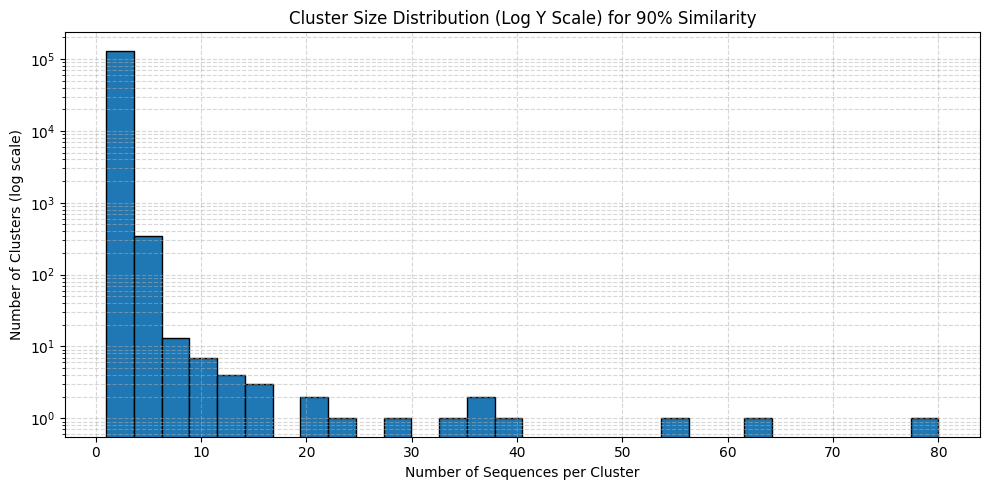

In [4]:
cluster_counts = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdhit_cluster_stats90.csv")
cluster_sizes = cluster_counts["total_sequences"].tolist()

plt.figure(figsize=(10, 5))
plt.hist(cluster_sizes, bins=30, edgecolor='black')
plt.yscale('log')  
plt.xlabel("Number of Sequences per Cluster")
plt.ylabel("Number of Clusters (log scale)")
plt.title("Cluster Size Distribution (Log Y Scale) for 90% Similarity")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(r"D:\Thesis EGFR dataset\Figures\cluster_size_distribution 90.png", dpi=300)
plt.show()

Add Labels to the Cluster list

In [15]:
list_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdhit_cluster_list90.csv")
full_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\new_filtered_aligned_seqs_merged.csv")
merged = list_df.merge(full_df[['Nanobody_id', 'Label']], on='Nanobody_id', how='left')

merged.to_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdhit_cluster_list90.csv", index=False)
print(len(merged))

141015


Graph of clusters with labels

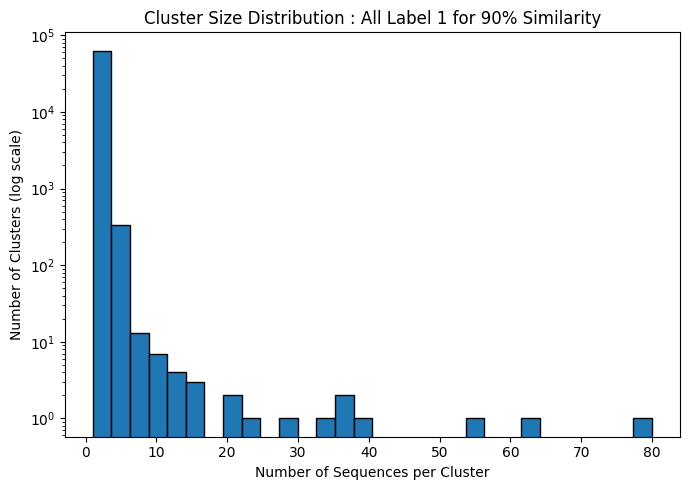

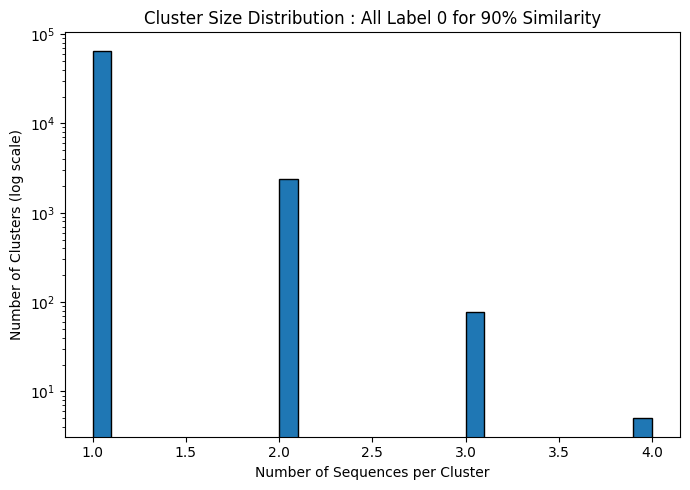

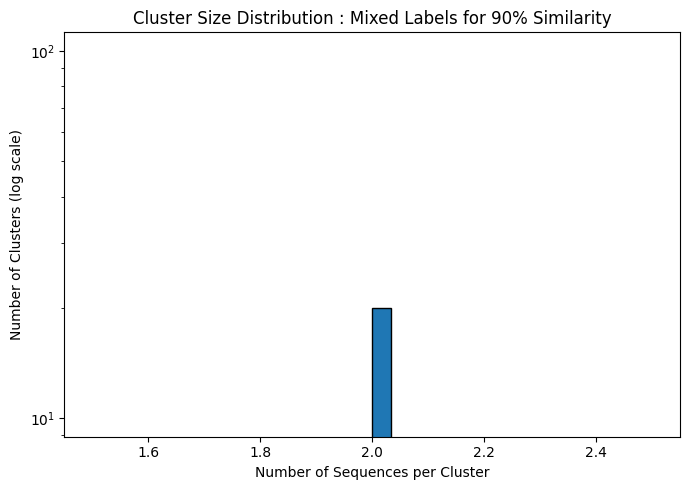

In [11]:
label_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdhit_cluster_stats90.csv")

all_label1 = label_df[(label_df["label_0"] == 0) & (label_df["label_1"] > 0)]
all_label0 = label_df[(label_df["label_1"] == 0) & (label_df["label_0"] > 0)]
mixed = label_df[(label_df["label_0"] > 0) & (label_df["label_1"] > 0)]

#All label 1
plt.figure(figsize=(7,5))
plt.hist(all_label1["total_sequences"], bins = 30, edgecolor='black')
plt.yscale('log')
plt.xlabel("Number of Sequences per Cluster")
plt.ylabel("Number of Clusters (log scale)")
plt.title("Cluster Size Distribution : All Label 1 for 90% Similarity")
plt.tight_layout()
plt.savefig(r"D:\Thesis EGFR dataset\Figures\all_label1_90.png", dpi=300)
plt.show()

#All label 0
plt.figure(figsize=(7,5))
plt.hist(all_label0["total_sequences"], bins = 30, edgecolor='black')
plt.yscale('log')
plt.xlabel("Number of Sequences per Cluster")
plt.ylabel("Number of Clusters (log scale)")
plt.title("Cluster Size Distribution : All Label 0 for 90% Similarity")
plt.tight_layout()
plt.savefig(r"D:\Thesis EGFR dataset\Figures\all_label0_90.png", dpi=300)
plt.show()

#Mixed clusters
plt.figure(figsize=(7,5))
plt.hist(mixed["total_sequences"], bins = 30, edgecolor='black')
plt.yscale('log')
plt.xlabel("Number of Sequences per Cluster")
plt.ylabel("Number of Clusters (log scale)")
plt.title("Cluster Size Distribution : Mixed Labels for 90% Similarity")
plt.tight_layout()
plt.savefig(r"D:\Thesis EGFR dataset\Figures\mixed_90.png", dpi=300)
plt.show()


In [12]:
# Load your file — update the path if needed
df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\cdhit_cluster_stats90.csv")

# Compute median cluster size from the total_sequences column
median_size = df["total_sequences"].median()

print("Median cluster size:", median_size)

Median cluster size: 1.0
